# Evaluating Model Robustness to Distribution Shift via SAM
**USC Viterbi — Hanchen Zou, Kaicheng Li, Siting Dai, Zhiqi Chen**

本 notebook 完整实现三个部分：

2. **PART 2** — 在 CIFAR-10 上训练 ResNet-18（SGD vs SAM）
3. **PART 3** — 在人工生成的 CIFAR-10-C 腐蚀数据上评估 OOD 鲁棒性

> ⚠️ **运行前确认**：Runtime → Change runtime type → Hardware accelerator → **GPU (T4)**

In [ ]:
# ============================================================
# CELL 1: 环境初始化
# ============================================================
# Prepared for CSCI 567 / USC Viterbi SAM Robustness Project
# References:
#   Foret et al. (2021) - SAM: Sharpness-Aware Minimization
#   Hendrycks & Dietterich (2019) - Benchmarking Neural Network Robustness

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

import time
import warnings
warnings.filterwarnings('ignore')

# ---- 随机种子（保证结果可复现）----
torch.manual_seed(42)
np.random.seed(42)

# ---- 设备检测 ----
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Using device: {device}')
if device.type == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('⚠️  No GPU detected! Training will be very slow.')
    print('   Go to: Runtime > Change runtime type > GPU')

✅ Using device: cuda
   GPU: Tesla T4
   Memory: 15.6 GB


---
## PART 2 — CIFAR-10 真实训练（ResNet-18: SGD vs SAM）

### 训练参数调试指南
| 参数 | 默认值 | 调试建议 |
|------|--------|----------|
| `EPOCHS` | 30 | 快速测试改 5；完整复现改 100-200 |
| `LR` | 0.1 | 标准 ResNet/SGD 设置；SAM 论文用相同值 |
| `SAM_RHO_TRAIN` | 0.05 | 论文推荐值；可试 0.01, 0.1, 0.2 |
| `BATCH_SIZE` | 128 | GPU OOM 时改 64 |
| `MOMENTUM` | 0.9 | 标准；通常不需要改 |
| `WEIGHT_DECAY` | 5e-4 | L2 正则；可试 1e-3 |

> ⏱️ 在 Colab T4 上，30 epochs 约 **5-8 分钟**（SGD）和 **10-15 分钟**（SAM）

In [ ]:
# ============================================================
# CELL 5: SAM 优化器完整实现
# 参考：Foret et al. (2021) "Sharpness-Aware Minimization for Efficiently
#       Improving Generalization"
# ============================================================

class SAM(torch.optim.Optimizer):
    """
    SAM（Sharpness-Aware Minimization）优化器

    核心思想：
    不直接最小化 L(w)，而是最小化最坏邻域的损失：
        min_w  max_{‖ε‖≤ρ}  L(w + ε)

    每次更新分两个 step：
    1. first_step()：找到最坏邻域点 ŵ = w + ρ*g/‖g‖，保存原始参数
    2. second_step()：在 ŵ 处计算梯度，恢复原始 w，用该梯度更新

    重要参数:
    - rho (ρ): 扰动半径，控制「平坦度」偏好的强度
      - 太小(→0): 退化为标准 SGD
      - 太大: 梯度估计不准，可能不收敛
      - 论文推荐: 0.05 (CIFAR-10), 0.01-0.2 是常用范围
    - adaptive: 若 True，使用 ASAM（自适应 SAM），对参数尺度不变
    """

    def __init__(self, params, base_optimizer, rho=0.05, adaptive=False, **kwargs):
        assert rho >= 0.0, f'rho 必须非负，当前值: {rho}'
        defaults = dict(rho=rho, adaptive=adaptive, **kwargs)
        super(SAM, self).__init__(params, defaults)

        # 使用基础优化器（通常是 SGD）来执行实际参数更新
        self.base_optimizer = base_optimizer(self.param_groups, **kwargs)
        self.param_groups = self.base_optimizer.param_groups
        self.defaults.update(self.base_optimizer.defaults)

    @torch.no_grad()
    def first_step(self, zero_grad=False):
        """
        第一步：计算并施加扰动 e_w
        e_w = ρ * g / ‖g‖   （对 adaptive SAM 有所不同）
        w_hat = w + e_w
        同时将原始 w 保存在 self.state[p]["old_p"] 中
        """
        grad_norm = self._grad_norm()
        for group in self.param_groups:
            scale = group['rho'] / (grad_norm + 1e-12)
            for p in group['params']:
                if p.grad is None:
                    continue
                self.state[p]['old_p'] = p.data.clone()  # 保存原始参数
                # Adaptive SAM: 对每个参数乘以 |p|（参数尺度归一化）
                e_w = (torch.pow(p, 2) if group['adaptive'] else 1.0) * p.grad * scale.to(p)
                p.add_(e_w)  # w = w + e_w （移动到最坏邻域）
        if zero_grad:
            self.zero_grad()

    @torch.no_grad()
    def second_step(self, zero_grad=False):
        """
        第二步：恢复原始参数，用扰动处的梯度做实际更新
        """
        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None:
                    continue
                p.data = self.state[p]['old_p']  # 恢复到原始 w
        self.base_optimizer.step()  # 用 ŵ 处梯度更新 w
        if zero_grad:
            self.zero_grad()

    def step(self, closure=None):
        """
        不使用这个接口！SAM 需要两次前向传播。
        请使用 first_step + second_step 配合 closure 模式。
        """
        raise NotImplementedError(
            'SAM 不支持标准 .step()。\n'
            '请参考 train_one_epoch_sam() 中的训练循环写法。'
        )

    def _grad_norm(self):
        """计算所有参数梯度的全局 L2 范数（用于归一化扰动方向）"""
        shared_device = self.param_groups[0]['params'][0].device
        norm = torch.norm(
            torch.stack([
                ((torch.abs(p) if group['adaptive'] else 1.0) * p.grad).norm(p=2).to(shared_device)
                for group in self.param_groups
                for p in group['params']
                if p.grad is not None
            ]),
            p=2
        )
        return norm

    def load_state_dict(self, state_dict):
        super().load_state_dict(state_dict)
        self.base_optimizer.param_groups = self.param_groups


print('✅ SAM 优化器类定义完成')
print(f'   论文推荐 rho = 0.05 (CIFAR-10/100)')

✅ SAM 优化器类定义完成
   论文推荐 rho = 0.05 (CIFAR-10/100)


In [ ]:
# ============================================================
# CELL 6: ResNet-18（CIFAR-10 适配版）
# ============================================================

def get_resnet18_cifar():
    """
    CIFAR-10 适配的 ResNet-18：

    标准 ResNet-18 为 ImageNet (224×224) 设计，直接用于 CIFAR-10 (32×32) 会
    因为 maxpool 和 stride=2 的 conv1 导致特征图过小。

    修改点：
    1. conv1: kernel 7→3, stride 2→1, padding 3→1（保留更多细节）
    2. maxpool: 替换为 Identity()（去掉，防止特征图太小）
    3. fc: 输出维度 1000→10（CIFAR-10 有 10 类）
    """
    model = models.resnet18(weights=None)  # 不加载预训练权重

    # 适配 CIFAR-10 的 32×32 输入
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()  # 去掉 maxpool
    model.fc = nn.Linear(512, 10)  # 10 分类

    return model


# 测试模型结构
_test_model = get_resnet18_cifar()
_test_input  = torch.randn(4, 3, 32, 32)
_test_output = _test_model(_test_input)
print(f'✅ ResNet-18 (CIFAR adapted)')
print(f'   输入: {_test_input.shape}')
print(f'   输出: {_test_output.shape}   (应为 [4, 10])')

# 参数量统计
n_params = sum(p.numel() for p in _test_model.parameters() if p.requires_grad)
print(f'   可训练参数: {n_params/1e6:.2f}M')
del _test_model, _test_input, _test_output

✅ ResNet-18 (CIFAR adapted)
   输入: torch.Size([4, 3, 32, 32])
   输出: torch.Size([4, 10])   (应为 [4, 10])
   可训练参数: 11.17M


In [ ]:
# ============================================================
# CELL 6b: 全局损失函数定义
# ============================================================
# 统一使用 Cross-Entropy Loss（多分类标准损失函数）
# PyTorch 的 CrossEntropyLoss 内部已包含 Softmax，
# 输入为 raw logits（模型输出），无需额外做 softmax。
criterion = nn.CrossEntropyLoss()
print(f'✅ 损失函数: {criterion}')


✅ 损失函数: CrossEntropyLoss()


In [ ]:
# ============================================================
# CELL 7: 数据加载器（CIFAR-10）+ 10% Validation Split
# ============================================================

# ====================================================================
# ★★★  训练超参数（默认值，将由超参数搜索覆盖）★★★
# ====================================================================
EPOCHS        = 100      # 最终训练轮数
BATCH_SIZE    = 128      # 批大小
LR            = 0.1      # 初始学习率（将由搜索覆盖）
MOMENTUM      = 0.9      # SGD 动量
WEIGHT_DECAY  = 5e-4     # L2 正则化（将由搜索覆盖）
SAM_RHO_TRAIN = 0.05     # SAM 扰动半径（将由搜索覆盖）
# ====================================================================

from torch.utils.data import random_split

# ---- 数据预处理 ----
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.4914, 0.4822, 0.4465),
                         std =(0.2470, 0.2435, 0.2616))
])
val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.4914, 0.4822, 0.4465),
                         std =(0.2470, 0.2435, 0.2616))
])
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.4914, 0.4822, 0.4465),
                         std =(0.2470, 0.2435, 0.2616))
])

# ---- 下载完整训练集 ----
print('正在下载 CIFAR-10...')
full_train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=train_transform)
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=test_transform)

# ---- 按 9:1 切分 train / val ----
total_train  = len(full_train_dataset)          # 50 000
val_size     = int(0.1 * total_train)           # 5 000
train_size   = total_train - val_size           # 45 000

torch.manual_seed(42)
train_dataset, val_dataset_raw = random_split(full_train_dataset,
                                               [train_size, val_size])

# Validation 不做数据增强：用 val_transform 重新包装
# 注意：random_split 不能直接换 transform，所以用 Subset + 新 Dataset 包装
class TransformSubset(torch.utils.data.Dataset):
    """给 Subset 数据集替换 transform"""
    def __init__(self, subset, transform):
        self.subset    = subset
        self.transform = transform
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, idx):
        img, label = self.subset.dataset.data[self.subset.indices[idx]], \
                     self.subset.dataset.targets[self.subset.indices[idx]]
        from PIL import Image
        img = Image.fromarray(img)
        if self.transform:
            img = self.transform(img)
        return img, label

val_dataset = TransformSubset(val_dataset_raw, val_transform)

# ---- DataLoader ----
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=256,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=256,
                          shuffle=False, num_workers=2, pin_memory=True)

CLASSES = ('airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

print(f'✅ 数据集加载完成')
print(f'   训练集 (90%): {train_size:,} 张 | {len(train_loader)} 批')
print(f'   验证集 (10%): {val_size:,}  张 | {len(val_loader)}  批')
print(f'   测试集:       {len(test_dataset):,}  张 | {len(test_loader)} 批')


正在下载 CIFAR-10...


100%|██████████| 170M/170M [00:06<00:00, 25.1MB/s]


✅ 数据集加载完成
   训练集 (90%): 45,000 张 | 352 批
   验证集 (10%): 5,000  张 | 20  批
   测试集:       10,000  张 | 40 批


In [ ]:
# ============================================================
# CELL 8: 训练与评估函数（含 Validation 支持）
# ============================================================

def train_one_epoch_sgd(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct    += outputs.argmax(1).eq(labels).sum().item()
        total      += images.size(0)
    if scheduler is not None:
        scheduler.step()
    return total_loss / total, 100.0 * correct / total


def train_one_epoch_sam(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.first_step(zero_grad=True)
        criterion(model(images), labels).backward()
        optimizer.second_step(zero_grad=True)
        total_loss += loss.item() * images.size(0)
        correct    += outputs.argmax(1).eq(labels).sum().item()
        total      += images.size(0)
    if scheduler is not None:
        scheduler.step()
    return total_loss / total, 100.0 * correct / total


@torch.no_grad()
def evaluate(model, loader, device):
    """使用全局 criterion (CrossEntropyLoss) 评估模型"""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss    = criterion(outputs, labels)
        total_loss += loss.item() * images.size(0)
        correct    += outputs.argmax(1).eq(labels).sum().item()
        total      += images.size(0)
    return total_loss / total, 100.0 * correct / total


def train_full(optimizer_name, model, optimizer, scheduler, train_loader,
               val_loader, test_loader, epochs, device, verbose=True):
    """
    完整训练循环。
    损失函数：CrossEntropyLoss（全局 criterion）
    同时追踪 train / val / test 指标，按验证集最优保存 checkpoint。
    """
    history = {'train_loss': [], 'train_acc': [],
               'val_loss':   [], 'val_acc':   [],
               'test_loss':  [], 'test_acc':  []}
    train_fn = (train_one_epoch_sam if optimizer_name == 'SAM'
                else train_one_epoch_sgd)

    best_val_acc = 0.0
    best_state   = None

    if verbose:
        print(f'\n{"="*70}')
        print(f'  训练 {optimizer_name} | {epochs} epochs | Loss: CrossEntropyLoss')
        print(f'{"="*70}')
        print(f'{"Epoch":>6} | {"Tr Loss":>8} | {"Tr Acc":>7} | '
              f'{"Val Loss":>8} | {"Val Acc":>7} | {"Te Acc":>7}')
        print(f'{"-"*70}')

    t0 = time.time()
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_fn(model, train_loader, optimizer, scheduler, device)
        va_loss, va_acc = evaluate(model, val_loader,   device)
        te_loss, te_acc = evaluate(model, test_loader,  device)

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(va_loss)
        history['val_acc'].append(va_acc)
        history['test_loss'].append(te_loss)
        history['test_acc'].append(te_acc)

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if verbose:
            eta = (time.time() - t0) / epoch * (epochs - epoch)
            eta_str = f'  ETA:{eta/60:.1f}m' if epoch % 5 == 0 else ''
            print(f'{epoch:>6} | {tr_loss:>8.4f} | {tr_acc:>6.2f}% | '
                  f'{va_loss:>8.4f} | {va_acc:>6.2f}% | {te_acc:>6.2f}%{eta_str}')

    model.load_state_dict(best_state)
    _, final_te = evaluate(model, test_loader, device)

    if verbose:
        print(f'{"="*70}')
        print(f'  Best Val Acc: {best_val_acc:.2f}%')
        print(f'  Final Test Acc (best-val ckpt): {final_te:.2f}%')
        print(f'  总训练时间: {(time.time()-t0)/60:.1f} 分钟')

    history['best_val_acc']   = best_val_acc
    history['final_test_acc'] = final_te
    return history


print('✅ 训练函数定义完成（Loss: CrossEntropyLoss | 含 Val 追踪 & Best-Checkpoint）')


✅ 训练函数定义完成（Loss: CrossEntropyLoss | 含 Val 追踪 & Best-Checkpoint）


---
## PART 2b — Hyperparameter Tuning（使用 Validation Set）

在正式训练前，对 **SGD** 和 **SAM** 分别做轻量级超参数搜索：
- 每组配置只训练 `HP_EPOCHS`（默认 8）轮，以 **验证集准确率** 作为选择标准。
- 搜索空间：
  - **SGD**：`lr` × `weight_decay`
  - **SAM**：`lr` × `weight_decay` × `rho`
- 搜索结束后自动将最优参数写入全局变量，供后续完整训练直接使用。

> ⏱️ 在 T4 GPU 上约 **3-6 分钟**（取决于搜索空间大小）


SGD 超参数搜索：12 种配置 × 8 epochs
  损失函数: CrossEntropyLoss
Config |     lr |      wd |  Val Acc |   Time
--------------------------------------------------
     1 |  0.010 |   1e-04 |   83.04% | 288.4s
     2 |  0.010 |   5e-04 |   82.92% | 292.0s
     3 |  0.010 |   1e-03 |   82.50% | 291.7s
     4 |  0.050 |   1e-04 |   85.52% | 291.8s
     5 |  0.050 |   5e-04 |   86.86% | 291.7s
     6 |  0.050 |   1e-03 |   87.76% | 291.2s
     7 |  0.100 |   1e-04 |   82.02% | 291.2s
     8 |  0.100 |   5e-04 |   85.42% | 291.3s
     9 |  0.100 |   1e-03 |   85.96% | 291.2s
    10 |  0.200 |   1e-04 |   70.60% | 290.1s
    11 |  0.200 |   5e-04 |   81.72% | 290.2s
    12 |  0.200 |   1e-03 |   82.74% | 290.2s

✅ SGD 最优超参数:
   lr           = 0.05
   weight_decay = 0.001
   Val Acc      = 87.76%


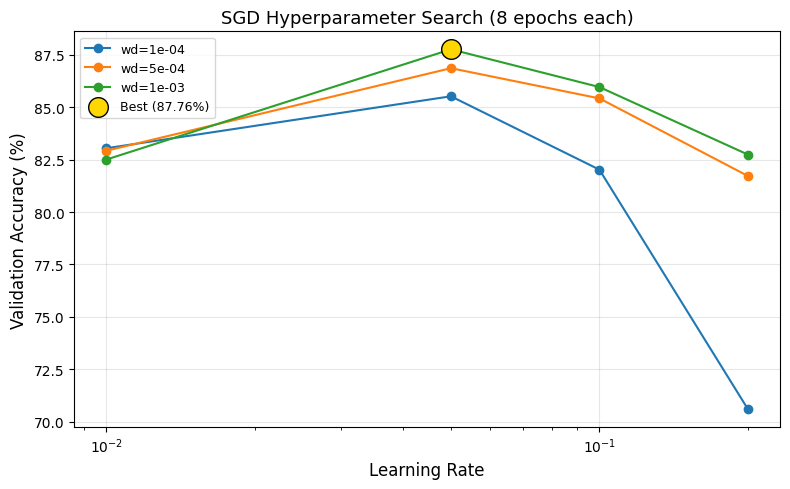

In [ ]:
# ============================================================
# CELL HP-SGD: SGD 超参数搜索（使用 CrossEntropyLoss）
# ============================================================

# ====================================================================
# ★★★ 搜索空间（按需扩展）★★★
# ====================================================================
HP_EPOCHS = 8

SGD_LR_GRID           = [0.01, 0.05, 0.1, 0.2]
SGD_WEIGHT_DECAY_GRID = [1e-4, 5e-4, 1e-3]
# ====================================================================

sgd_hp_results = []
total_configs = len(SGD_LR_GRID) * len(SGD_WEIGHT_DECAY_GRID)
print(f'SGD 超参数搜索：{total_configs} 种配置 × {HP_EPOCHS} epochs')
print(f'  损失函数: CrossEntropyLoss')
print(f'{"Config":>6} | {"lr":>6} | {"wd":>7} | {"Val Acc":>8} | {"Time":>6}')
print('-' * 50)

cfg_idx = 0
for lr_cand in SGD_LR_GRID:
    for wd_cand in SGD_WEIGHT_DECAY_GRID:
        cfg_idx += 1
        torch.manual_seed(42)
        _model = get_resnet18_cifar().to(device)
        _opt   = torch.optim.SGD(_model.parameters(),
                                  lr=lr_cand, momentum=MOMENTUM,
                                  weight_decay=wd_cand)
        _sch   = torch.optim.lr_scheduler.CosineAnnealingLR(
                     _opt, T_max=HP_EPOCHS, eta_min=0)

        t0 = time.time()
        for ep in range(HP_EPOCHS):
            train_one_epoch_sgd(_model, train_loader, _opt, _sch, device)
        _, val_acc = evaluate(_model, val_loader, device)
        elapsed = time.time() - t0

        sgd_hp_results.append({'lr': lr_cand, 'wd': wd_cand, 'val_acc': val_acc})
        print(f'{cfg_idx:>6} | {lr_cand:>6.3f} | {wd_cand:>7.0e} | '
              f'{val_acc:>7.2f}% | {elapsed:>5.1f}s')
        del _model, _opt, _sch

best_sgd_hp  = max(sgd_hp_results, key=lambda x: x['val_acc'])
LR           = best_sgd_hp['lr']
WEIGHT_DECAY = best_sgd_hp['wd']

print(f'\n✅ SGD 最优超参数:')
print(f'   lr           = {LR}')
print(f'   weight_decay = {WEIGHT_DECAY}')
print(f'   Val Acc      = {best_sgd_hp["val_acc"]:.2f}%')

import itertools
fig, ax = plt.subplots(figsize=(8, 5))
for wd in SGD_WEIGHT_DECAY_GRID:
    accs = [r['val_acc'] for r in sgd_hp_results if r['wd'] == wd]
    ax.plot(SGD_LR_GRID, accs, marker='o', label=f'wd={wd:.0e}')
ax.scatter([best_sgd_hp['lr']], [best_sgd_hp['val_acc']], color='gold', s=200,
           zorder=5, edgecolors='k', label=f'Best ({best_sgd_hp["val_acc"]:.2f}%)')
ax.set_xlabel('Learning Rate', fontsize=12)
ax.set_ylabel('Validation Accuracy (%)', fontsize=12)
ax.set_title(f'SGD Hyperparameter Search ({HP_EPOCHS} epochs each)', fontsize=13)
ax.set_xscale('log')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('sgd_hp_search.png', dpi=120, bbox_inches='tight')
plt.show()


In [ ]:
# ============================================================
# CELL HP-SAM: SAM 超参数搜索（使用 CrossEntropyLoss）
# ============================================================

# ====================================================================
# ★★★ 搜索空间（按需扩展）★★★
# ====================================================================
HP_EPOCHS = 8 # Added definition for HP_EPOCHS

SAM_LR_GRID           = [0.05, 0.1, 0.2]
SAM_WEIGHT_DECAY_GRID = [1e-4, 5e-4, 1e-3]
SAM_RHO_GRID          = [0.01, 0.05, 0.1, 0.2]
# ====================================================================

sam_hp_results = []
total_configs = len(SAM_LR_GRID) * len(SAM_WEIGHT_DECAY_GRID) * len(SAM_RHO_GRID)
print(f'SAM 超参数搜索：{total_configs} 种配置 × {HP_EPOCHS} epochs')
print(f'  损失函数: CrossEntropyLoss')
print(f'{"Config":>6} | {"lr":>6} | {"wd":>7} | {"rho":>5} | {"Val Acc":>8} | {"Time":>6}')
print('-' * 58)

cfg_idx = 0
for lr_cand in SAM_LR_GRID:
    for wd_cand in SAM_WEIGHT_DECAY_GRID:
        for rho_cand in SAM_RHO_GRID:
            cfg_idx += 1
            torch.manual_seed(42)
            _model = get_resnet18_cifar().to(device)
            _opt   = SAM(_model.parameters(), torch.optim.SGD,
                          rho=rho_cand, lr=lr_cand,
                          momentum=MOMENTUM, weight_decay=wd_cand)
            _sch   = torch.optim.lr_scheduler.CosineAnnealingLR(
                         _opt.base_optimizer, T_max=HP_EPOCHS, eta_min=0)

            t0 = time.time()
            for ep in range(HP_EPOCHS):
                train_one_epoch_sam(_model, train_loader, _opt, _sch, device)
            _, val_acc = evaluate(_model, val_loader, device)
            elapsed = time.time() - t0

            sam_hp_results.append(
                {'lr': lr_cand, 'wd': wd_cand, 'rho': rho_cand, 'val_acc': val_acc})
            print(f'{cfg_idx:>6} | {lr_cand:>6.3f} | {wd_cand:>7.0e} | '
                  f'{rho_cand:>5.2f} | {val_acc:>7.2f}% | {elapsed:>5.1f}s')
            del _model, _opt, _sch

best_sam_hp   = max(sam_hp_results, key=lambda x: x['val_acc'])
LR            = best_sam_hp['lr']
WEIGHT_DECAY  = best_sam_hp['wd']
SAM_RHO_TRAIN = best_sam_hp['rho']

print(f'\n✅ SAM 最优超参数:')
print(f'   lr           = {LR}')
print(f'   weight_decay = {WEIGHT_DECAY}')
print(f'   rho          = {SAM_RHO_TRAIN}')
print(f'   Val Acc      = {best_sam_hp["val_acc"]:.2f}%')

fig, axes = plt.subplots(1, len(SAM_RHO_GRID), figsize=(5*len(SAM_RHO_GRID), 5), sharey=True)
if len(SAM_RHO_GRID) == 1:
    axes = [axes]
for ax, rho_v in zip(axes, SAM_RHO_GRID):
    for wd in SAM_WEIGHT_DECAY_GRID:
        accs = [r['val_acc'] for r in sam_hp_results
                if r['rho'] == rho_v and r['wd'] == wd]
        ax.plot(SAM_LR_GRID, accs, marker='s', label=f'wd={wd:.0e}')
    ax.set_title(f'ρ = {rho_v}', fontsize=12)
    ax.set_xlabel('Learning Rate')
    ax.set_xscale('log')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
axes[0].set_ylabel('Validation Accuracy (%)')
fig.suptitle(f'SAM Hyperparameter Search ({HP_EPOCHS} epochs each)', fontsize=13)
plt.tight_layout()
plt.savefig('sam_hp_search.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\n📋 将使用以下超参数进行完整训练:')
print(f'   LR={LR}, WEIGHT_DECAY={WEIGHT_DECAY}, SAM_RHO_TRAIN={SAM_RHO_TRAIN}')


SAM 超参数搜索：36 种配置 × 8 epochs
  损失函数: CrossEntropyLoss
Config |     lr |      wd |   rho |  Val Acc |   Time
----------------------------------------------------------
     1 |  0.050 |   1e-04 |  0.01 |   83.74% | 579.6s
     2 |  0.050 |   1e-04 |  0.05 |   83.04% | 580.2s


In [ ]:
# ============================================================
# CELL 9: 训练 SGD 模型（使用超参数搜索得到的最优参数）
# ============================================================

sgd_model = get_resnet18_cifar().to(device)
sgd_optimizer = torch.optim.SGD(
    sgd_model.parameters(),
    lr=LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY
)
sgd_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    sgd_optimizer, T_max=EPOCHS, eta_min=0)

print(f'SGD 完整训练  lr={LR}, wd={WEIGHT_DECAY}, epochs={EPOCHS}')
sgd_history = train_full(
    optimizer_name='SGD',
    model=sgd_model,
    optimizer=sgd_optimizer,
    scheduler=sgd_scheduler,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    epochs=EPOCHS,
    device=device
)

torch.save(sgd_model.state_dict(), 'sgd_model.pth')
print('\n✅ SGD 模型已保存为 sgd_model.pth')


In [ ]:
# ============================================================
# CELL 10: 训练 SAM 模型（使用超参数搜索得到的最优参数）
# ============================================================

sam_model = get_resnet18_cifar().to(device)
sam_optimizer = SAM(
    params=sam_model.parameters(),
    base_optimizer=torch.optim.SGD,
    rho=SAM_RHO_TRAIN,
    adaptive=False,
    lr=LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY
)
sam_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    sam_optimizer.base_optimizer, T_max=EPOCHS, eta_min=0)

print(f'SAM 完整训练  lr={LR}, wd={WEIGHT_DECAY}, rho={SAM_RHO_TRAIN}, epochs={EPOCHS}')
sam_history = train_full(
    optimizer_name='SAM',
    model=sam_model,
    optimizer=sam_optimizer,
    scheduler=sam_scheduler,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    epochs=EPOCHS,
    device=device
)

torch.save(sam_model.state_dict(), 'sam_model.pth')
print('\n✅ SAM 模型已保存为 sam_model.pth')


In [ ]:
# ============================================================
# CELL 11: 训练曲线对比图（Train / Val / Test）
# ============================================================

epochs_range = np.arange(1, EPOCHS + 1)
mk = max(1, EPOCHS // 10)    # 标记间隔

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# ── 训练损失 ────────────────────────────────────────────────
ax = axes[0, 0]
ax.plot(epochs_range, sgd_history['train_loss'], 'r-o', ms=4, lw=2,
        markevery=mk, label='SGD')
ax.plot(epochs_range, sam_history['train_loss'], 'b-s', ms=4, lw=2,
        markevery=mk, label=f'SAM (ρ={SAM_RHO_TRAIN})')
ax.set(xlabel='Epoch', ylabel='Loss', title='Training Loss')
ax.legend(); ax.grid(True, alpha=0.3)

# ── 验证损失 ────────────────────────────────────────────────
ax = axes[0, 1]
ax.plot(epochs_range, sgd_history['val_loss'], 'r-o', ms=4, lw=2,
        markevery=mk, label='SGD')
ax.plot(epochs_range, sam_history['val_loss'], 'b-s', ms=4, lw=2,
        markevery=mk, label=f'SAM (ρ={SAM_RHO_TRAIN})')
ax.set(xlabel='Epoch', ylabel='Loss', title='Validation Loss')
ax.legend(); ax.grid(True, alpha=0.3)

# ── 测试损失 ────────────────────────────────────────────────
ax = axes[0, 2]
ax.plot(epochs_range, sgd_history['test_loss'], 'r-o', ms=4, lw=2,
        markevery=mk, label='SGD')
ax.plot(epochs_range, sam_history['test_loss'], 'b-s', ms=4, lw=2,
        markevery=mk, label=f'SAM (ρ={SAM_RHO_TRAIN})')
ax.set(xlabel='Epoch', ylabel='Loss', title='Test Loss')
ax.legend(); ax.grid(True, alpha=0.3)

# ── 训练准确率 ───────────────────────────────────────────────
ax = axes[1, 0]
ax.plot(epochs_range, sgd_history['train_acc'], 'r-o', ms=4, lw=2,
        markevery=mk, label='SGD')
ax.plot(epochs_range, sam_history['train_acc'], 'b-s', ms=4, lw=2,
        markevery=mk, label=f'SAM (ρ={SAM_RHO_TRAIN})')
ax.set(xlabel='Epoch', ylabel='Accuracy (%)', title='Training Accuracy')
ax.legend(); ax.grid(True, alpha=0.3)

# ── 验证准确率 ───────────────────────────────────────────────
ax = axes[1, 1]
ax.plot(epochs_range, sgd_history['val_acc'], 'r-o', ms=4, lw=2,
        markevery=mk, label='SGD')
ax.plot(epochs_range, sam_history['val_acc'], 'b-s', ms=4, lw=2,
        markevery=mk, label=f'SAM (ρ={SAM_RHO_TRAIN})')
ax.set(xlabel='Epoch', ylabel='Accuracy (%)', title='Validation Accuracy')
ax.legend(); ax.grid(True, alpha=0.3)

# ── 测试准确率 ───────────────────────────────────────────────
ax = axes[1, 2]
ax.plot(epochs_range, sgd_history['test_acc'], 'r-o', ms=4, lw=2,
        markevery=mk, label='SGD')
ax.plot(epochs_range, sam_history['test_acc'], 'b-s', ms=4, lw=2,
        markevery=mk, label=f'SAM (ρ={SAM_RHO_TRAIN})')
sgd_best = max(sgd_history['test_acc'])
sam_best = max(sam_history['test_acc'])
ax.axhline(sgd_best, color='r', ls=':', alpha=0.5)
ax.axhline(sam_best, color='b', ls=':', alpha=0.5)
ax.text(EPOCHS*0.05, sgd_best+0.3, f'SGD best: {sgd_best:.2f}%', color='r', fontsize=9)
ax.text(EPOCHS*0.05, sam_best+0.3, f'SAM best: {sam_best:.2f}%', color='b', fontsize=9)
ax.set(xlabel='Epoch', ylabel='Accuracy (%)', title='Test Accuracy (Clean CIFAR-10)')
ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle(
    f'SGD vs SAM Training Curves\n'
    f'ResNet-18 | {EPOCHS} epochs | lr={LR} | wd={WEIGHT_DECAY} | ρ={SAM_RHO_TRAIN}',
    fontsize=13)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📊 训练结果汇总:')
print(f'   SGD — Best Val: {sgd_history["best_val_acc"]:.2f}%  '
      f'Final Test: {sgd_history["final_test_acc"]:.2f}%')
print(f'   SAM — Best Val: {sam_history["best_val_acc"]:.2f}%  '
      f'Final Test: {sam_history["final_test_acc"]:.2f}%')


---
## PART 3 — OOD 鲁棒性评估（使用官方 CIFAR-10-C 数据集）

使用 **Hendrycks & Dietterich (2019)** 发布的官方 [CIFAR-10-C](https://zenodo.org/record/2535967) 数据集，
在真实腐蚀数据上评估模型鲁棒性。

CIFAR-10-C 包含 **19 种腐蚀** × **5 个严重程度**，每组 10,000 张图像，
标签与原始 CIFAR-10 测试集完全相同（直接复用 `cifar10_labels.npy`）。

| 腐蚀大类 | 包含类型 |
|---------|----------|
| Noise   | gaussian_noise, shot_noise, impulse_noise |
| Blur    | defocus_blur, glass_blur, motion_blur, zoom_blur |
| Weather | snow, frost, fog, brightness |
| Digital | contrast, elastic_transform, pixelate, jpeg_compression |

> ⚠️ **数据下载**：脚本会自动从 Zenodo 下载（~800 MB），Colab 上首次运行约需 2–5 分钟。
> 如已下载，将跳过。


In [ ]:
# ============================================================
# CELL 12: 下载并加载官方 CIFAR-10-C 数据集
# 数据来源：Hendrycks & Dietterich (2019)
# https://zenodo.org/record/2535967
# ============================================================

import os
import urllib.request
import tarfile
import numpy as np

CIFAR10C_DIR = './data/CIFAR-10-C'
CIFAR10C_URL = 'https://zenodo.org/record/2535967/files/CIFAR-10-C.tar'

# ---- 自动下载（如果尚未下载）----
if not os.path.isdir(CIFAR10C_DIR):
    os.makedirs('./data', exist_ok=True)
    print('正在下载 CIFAR-10-C (~800 MB)...')
    tar_path = './data/CIFAR-10-C.tar'

    def _progress(block_num, block_size, total_size):
        done = block_num * block_size
        pct  = min(done / total_size * 100, 100)
        if block_num % 500 == 0:
            print(f'  {pct:.1f}%  ({done/1e6:.0f} / {total_size/1e6:.0f} MB)', end='\r')

    urllib.request.urlretrieve(CIFAR10C_URL, tar_path, reporthook=_progress)
    print('\n解压中...')
    with tarfile.open(tar_path) as tar:
        tar.extractall('./data')
    os.remove(tar_path)
    print('✅ 下载完成：', CIFAR10C_DIR)
else:
    print('✅ CIFAR-10-C 已存在，跳过下载')

# ---- 查看可用腐蚀类型 ----
npy_files = sorted([
    f[:-4] for f in os.listdir(CIFAR10C_DIR)
    if f.endswith('.npy') and f != 'labels.npy'
])
print(f'\n共 {len(npy_files)} 种腐蚀:')
for i, name in enumerate(npy_files):
    print(f'  {i+1:2d}. {name}')

# ---- 加载标签（所有腐蚀共用）----
CIFAR10C_LABELS = np.load(os.path.join(CIFAR10C_DIR, 'labels.npy'))
# labels.npy shape: (50000,) — 5 severity × 10000 images, stacked

CIFAR10C_CORRUPTIONS = npy_files  # 全部 19 种，或按需筛选

# CIFAR-10 归一化参数（与训练时保持一致）
CIFAR_MEAN = torch.tensor([0.4914, 0.4822, 0.4465])
CIFAR_STD  = torch.tensor([0.2470, 0.2435, 0.2616])

print(f'\n✅ 标签加载完成，shape: {CIFAR10C_LABELS.shape}')
print(f'   每种腐蚀评估场景：{len(CIFAR10C_CORRUPTIONS)} 种 × 5 severity = {len(CIFAR10C_CORRUPTIONS)*5} 组')

In [ ]:
# ============================================================
# CELL 13: OOD 鲁棒性评估（官方 CIFAR-10-C）
# ============================================================

from torch.utils.data import TensorDataset, DataLoader as DL

@torch.no_grad()
def evaluate_cifar10c(model, corruption_name, severity, device, batch_size=256):
    """
    在指定腐蚀类型 + severity 上评估模型准确率。

    CIFAR-10-C 文件结构：
      每个 .npy 文件 shape = (50000, 32, 32, 3)，uint8，值域 [0, 255]
      前 10000 张 = severity 1，..., 最后 10000 张 = severity 5
    标签：labels.npy shape = (50000,)，同上顺序
    """
    model.eval()

    npy_path = os.path.join(CIFAR10C_DIR, f'{corruption_name}.npy')
    data_all  = np.load(npy_path)          # (50000, 32, 32, 3) uint8
    label_all = CIFAR10C_LABELS            # (50000,)

    # 取对应 severity 的 10000 张
    start = (severity - 1) * 10000
    end   = severity * 10000
    data  = data_all[start:end]            # (10000, 32, 32, 3)
    labels = label_all[start:end]          # (10000,)

    # uint8 → float [0,1] → (N, C, H, W)
    x = torch.from_numpy(data).float() / 255.0          # (N,32,32,3)
    x = x.permute(0, 3, 1, 2)                           # (N,3,32,32)

    # CIFAR-10 归一化
    mean = CIFAR_MEAN.view(1, 3, 1, 1)
    std  = CIFAR_STD.view(1, 3, 1, 1)
    x = (x - mean) / std

    y = torch.from_numpy(labels).long()

    dataset = TensorDataset(x, y)
    loader  = DL(dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    correct, total = 0, 0
    for images, lbls in loader:
        images, lbls = images.to(device), lbls.to(device)
        outputs = model(images)
        correct += outputs.argmax(1).eq(lbls).sum().item()
        total   += lbls.size(0)

    return 100.0 * correct / total


# ---- 执行完整评估 ----
# 可以评估全部 19 种，或只选感兴趣的子集
EVAL_CORRUPTIONS = CIFAR10C_CORRUPTIONS  # 全部；或改为如 ['gaussian_noise', 'motion_blur', 'snow']

print(f'开始 OOD 鲁棒性评估：{len(EVAL_CORRUPTIONS)} 种腐蚀 × 5 severity')
print(f'{"Corruption":<25} | {"Sev":>3} | {"SGD":>7} | {"SAM":>7} | {"Δ":>6}')
print('-' * 60)

results = {}

for c_name in EVAL_CORRUPTIONS:
    results[c_name] = {'SGD': [], 'SAM': []}
    for sev in range(1, 6):
        sgd_acc = evaluate_cifar10c(sgd_model, c_name, sev, device)
        sam_acc = evaluate_cifar10c(sam_model, c_name, sev, device)
        results[c_name]['SGD'].append(sgd_acc)
        results[c_name]['SAM'].append(sam_acc)
        delta = sam_acc - sgd_acc
        print(f'{c_name:<25} | {sev:>3} | {sgd_acc:>6.1f}% | {sam_acc:>6.1f}% | '
              f'{delta:>+5.1f}%')

# ---- mCE（mean Corruption Error）----
sgd_mCE = np.mean([100 - acc for c in results for acc in results[c]['SGD']])
sam_mCE = np.mean([100 - acc for c in results for acc in results[c]['SAM']])

clean_sgd = sgd_history['test_acc'][-1]
clean_sam = sam_history['test_acc'][-1]

print(f'\n📊 OOD 鲁棒性汇总（官方 CIFAR-10-C）:')
print(f'   干净测试集: SGD={clean_sgd:.2f}%  SAM={clean_sam:.2f}%')
print(f'   mCE (↓越好): SGD={sgd_mCE:.2f}%  SAM={sam_mCE:.2f}%')
print(f'   SAM 相对改善: {sgd_mCE - sam_mCE:+.2f}%')


In [ ]:
# ============================================================
# CELL 14: Exp 1 — 严重程度敏感性分析图
# （对应 midterm 中 Exp 1：Track performance decay by severity）
# ============================================================

severity_levels = [1, 2, 3, 4, 5]
n_corruptions   = len(CORRUPTIONS)
corruption_names = list(CORRUPTIONS.keys())

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (c_name, ax) in enumerate(zip(corruption_names, axes)):
    sgd_accs = results[c_name]['SGD']
    sam_accs = results[c_name]['SAM']

    ax.plot(severity_levels, sgd_accs, 'r-o', linewidth=2.5,
            markersize=8, label='SGD')
    ax.plot(severity_levels, sam_accs, 'b-s', linewidth=2.5,
            markersize=8, label=f'SAM (ρ={SAM_RHO_TRAIN})')

    # 标注干净基线
    ax.axhline(clean_sgd, color='r', linestyle=':', alpha=0.5, linewidth=1.2)
    ax.axhline(clean_sam, color='b', linestyle=':', alpha=0.5, linewidth=1.2)

    # 填充两条曲线之间的差异区域
    ax.fill_between(severity_levels,
                    [min(s, g) for s, g in zip(sam_accs, sgd_accs)],
                    [max(s, g) for s, g in zip(sam_accs, sgd_accs)],
                    alpha=0.15, color='purple', label='Difference')

    display_name = c_name.replace('\n', ' ')
    ax.set_title(display_name, fontsize=13, fontweight='bold')
    ax.set_xlabel('Corruption Severity', fontsize=11)
    ax.set_ylabel('Test Accuracy (%)', fontsize=11)
    ax.set_xticks(severity_levels)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(max(0, min(min(sgd_accs), min(sam_accs)) - 5), 100)

plt.suptitle(
    f'Exp 1: Severity Sensitivity — SGD vs SAM (ρ={SAM_RHO_TRAIN})\n'
    f'ResNet-18 | CIFAR-10-C Style | {EPOCHS} Epochs',
    fontsize=14
)
plt.tight_layout()
plt.savefig('exp1_severity_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print('图已保存为 exp1_severity_sensitivity.png')

In [ ]:
# ============================================================
# CELL 15: 综合对比图（雷达图 + 柱状图）
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ---- 左图：各腐蚀平均准确率柱状图 ----
ax = axes[0]

display_names = [c.replace('\n', ' ') for c in corruption_names]
sgd_mean_per_corruption = [np.mean(results[c]['SGD']) for c in corruption_names]
sam_mean_per_corruption = [np.mean(results[c]['SAM']) for c in corruption_names]

x = np.arange(len(corruption_names))
width = 0.35
bars_sgd = ax.bar(x - width/2, sgd_mean_per_corruption, width,
                   color='#E74C3C', alpha=0.85, label='SGD', edgecolor='darkred')
bars_sam = ax.bar(x + width/2, sam_mean_per_corruption, width,
                   color='#3498DB', alpha=0.85, label=f'SAM (ρ={SAM_RHO_TRAIN})', edgecolor='darkblue')

# 标注数值
for bar in bars_sgd:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8, color='darkred')
for bar in bars_sam:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8, color='darkblue')

# 干净基线
ax.axhline(clean_sgd, color='r', linestyle='--', linewidth=1.5,
            label=f'SGD clean: {clean_sgd:.1f}%')
ax.axhline(clean_sam, color='b', linestyle='--', linewidth=1.5,
            label=f'SAM clean: {clean_sam:.1f}%')

ax.set_xticks(x)
ax.set_xticklabels(display_names, fontsize=10)
ax.set_ylabel('Mean Accuracy Across Severities (%)', fontsize=11)
ax.set_title('Mean Accuracy per Corruption Type\n(averaged over severity 1-5)', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(max(0, min(min(sgd_mean_per_corruption), min(sam_mean_per_corruption)) - 5), 100)

# ---- 右图：各严重程度平均准确率折线图 ----
ax2 = axes[1]

sgd_mean_per_severity = [
    np.mean([results[c]['SGD'][s] for c in corruption_names])
    for s in range(5)
]
sam_mean_per_severity = [
    np.mean([results[c]['SAM'][s] for c in corruption_names])
    for s in range(5)
]

ax2.plot(severity_levels, sgd_mean_per_severity, 'r-o',
          linewidth=2.5, markersize=10, label='SGD')
ax2.plot(severity_levels, sam_mean_per_severity, 'b-s',
          linewidth=2.5, markersize=10, label=f'SAM (ρ={SAM_RHO_TRAIN})')
ax2.fill_between(severity_levels,
                  [min(s, g) for s, g in zip(sam_mean_per_severity, sgd_mean_per_severity)],
                  [max(s, g) for s, g in zip(sam_mean_per_severity, sgd_mean_per_severity)],
                  alpha=0.2, color='purple')

# 标注数值
for s, (sg, sm) in enumerate(zip(sgd_mean_per_severity, sam_mean_per_severity)):
    ax2.annotate(f'{sg:.1f}%', (s+1, sg), textcoords='offset points',
                  xytext=(-15, 5), fontsize=9, color='r')
    ax2.annotate(f'{sm:.1f}%', (s+1, sm), textcoords='offset points',
                  xytext=(3, 5), fontsize=9, color='b')

ax2.set_xlabel('Corruption Severity Level', fontsize=12)
ax2.set_ylabel('Mean Accuracy (%) — All Corruptions', fontsize=11)
ax2.set_title('Mean Robustness vs Corruption Severity\n(averaged over all corruption types)', fontsize=12)
ax2.set_xticks(severity_levels)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.suptitle(
    f'OOD Robustness Summary — SGD vs SAM\n'
    f'SGD mCE={sgd_mCE:.1f}%  |  SAM mCE={sam_mCE:.1f}%  '
    f'(SAM改善 {sgd_mCE-sam_mCE:+.1f}%)',
    fontsize=14
)
plt.tight_layout()
plt.savefig('robustness_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('图已保存为 robustness_summary.png')

In [ ]:
# ============================================================
# CELL 17: 最终结果汇总表
# ============================================================

print('\n' + '='*65)
print('  FINAL RESULTS SUMMARY')
print('='*65)
print(f'  Model Architecture : ResNet-18 (CIFAR-adapted)')
print(f'  Training Epochs    : {EPOCHS}')
print(f'  Batch Size         : {BATCH_SIZE}')
print(f'  Learning Rate      : {LR}')
print(f'  Momentum           : {MOMENTUM}')
print(f'  Weight Decay       : {WEIGHT_DECAY}')
print(f'  SAM ρ              : {SAM_RHO_TRAIN}')
print('='*65)
print(f'  {"Metric":<35} {"SGD":>8} {"SAM":>8} {"Δ":>8}')
print('-'*65)
print(f'  {"Clean Test Accuracy":35} {clean_sgd:>7.2f}% {clean_sam:>7.2f}% {clean_sam-clean_sgd:>+7.2f}%')
print(f'  {"Mean Corruption Error (mCE)":35} {sgd_mCE:>7.2f}% {sam_mCE:>7.2f}% {sam_mCE-sgd_mCE:>+7.2f}%')
print('-'*65)

for c_name in corruption_names:
    display = c_name.replace('\n', ' ')
    sgd_m = np.mean(results[c_name]['SGD'])
    sam_m = np.mean(results[c_name]['SAM'])
    print(f'  Mean Acc: {display:<25} {sgd_m:>7.2f}% {sam_m:>7.2f}% {sam_m-sgd_m:>+7.2f}%')